<h3 align="center">
Skeelam distribution
</h3>

In this notebook, we will learn about the <u>Skeelam distribution</u>, which is used to model **the difference of 2 poisson distributed random variables**

Each distribution usually comes with a probability function, in this case, the difference of 2 discrete RV is also a distribution of discrete values. Thus Skeelam has a probability mass function.

We will **derive** the beautiful Maths of Skeelam. 

As always, I will show you how simple it is to **simulate** this random variable.

In [92]:
from scipy.stats import poisson, skellam
import numpy as np
import matplotlib.pyplot as plt
import math

#### **I. The Maths**

**1. Poisson**

+ We start with having 2 Poisson Random Variables (independent)

$$
N_1 \sim Pois(\mu_1) \\
N_2 \sim Pois(\mu_2)
$$

+ Then the difference follows a Skeelam Distribution

$$
D = N_1 - N_2 \sim Skeelam(.) \\ 
-\infty < d < \infty
$$

I put nothing in the parameter, because we dont know what does it look like.

**2. Law of total probability**

For a value of D such as d, there can be infinitely many ways of choosing N1 and N2.

<u>For example:</u> $d = 3$, then N1 can be 4 and N2 can be 1 or N1 and N2 be 6 and 3 respectively.

Since the 2 random variables are independent and Poisson distributed, we can use **the law of total probability** as follow:

$$
P(D = d) = \sum P(N_1 = n_1 \cap N_2 = n_1 - d) \\

= \sum \frac{e^{-\mu_1} \mu_1^{n_1}}{n_1 !} \cdot \frac{e^{-\mu_2} \mu_2^{n_2}}{n_2 !} \\

= e^{-(\mu_1 + \mu_2)} \sum \frac{\mu_1^{n_1}}{n_1 !} \cdot \frac{\mu_2^{n_2}}{n_2 !}
$$

You may have noticed, I did not plug in $n_2 = n_1 - d$, because we will need to use some cautions.

**3. Difference can be positive, and also negative**

Because we define $D = N_1 - N_2$, then there are 2 cases to be considered:

1. When $d \ge 0$

    Remember, probability of a negative value in Poisson is 0. Thus, $n_1$ starts from $d$

$$P(D = d) = e^{-(\mu_1 + \mu_2)} \sum_{n_1 = d}^{\infty} \frac{\mu_1^{n_1}}{n_1 !} \cdot \frac{\mu_2^{n_1 - d}}{(n_1 - d) !}$$


2. When $d \lt 0$

    If $d$ negative, it means $n_2 > n_1$, thus a good idea is just to do the same process to $n_2$ as we did for $n_1$

$$P(D = d) = e^{-(\mu_1 + \mu_2)} \sum_{n_2 = -d}^{\infty} \frac{\mu_1^{n_2 + d}}{(n_2 + d) !} \cdot \frac{\mu_2^{n_2}}{n_2 !}$$

**4. The mean and variance** 

The mean of Skeelam random variable is
$$
E[N_1 - N_2] \\
= E[N_1] - E[N_2] \\
= \mu_1 - \mu_2
$$

We can also get the variance
$$
Var[N_1 - N_2] \\
= Var[N_1] + Var[N_2] \\
= \mu_1 + \mu_2
$$

We can also make this look simpler by using a thing called **Bessel Series**, but I will not discuss it here.

In [102]:
#Function to Calculate pmf of D.

#However, it works for small number only. So use Scipy

def dskeelam(mu_1, mu_2, d):

    A = np.exp(-(mu_1 + mu_2))

    B = 0

    if d >= 0:
        for n1 in range(d, d + 40):

            B += (mu_1 ** n1 / math.factorial(n1)) * (mu_2 ** (n1 - d) / math.factorial(n1 - d))

    else:
        for n2 in range(-d, -d + 40):

            B += (mu_1 ** (n2 + d) / math.factorial(n2 + d)) * (mu_2 ** (n2) / math.factorial(n2))

    return A * B 

We can plot the distribution

In [ ]:
mu_1 = 40
mu_2 = 10

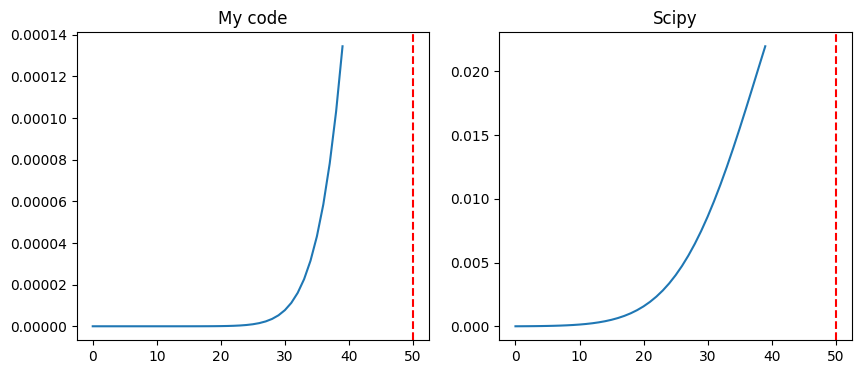

In [155]:
fig, axs = plt.subplots(1, 2, figsize = (10, 4))

d_arr = list(range(0, 40))

prob_arr = np.array([dskeelam(mu_1, mu_2, d) for d in d_arr])

axs[0].plot(d_arr, prob_arr)

axs[0].axvline(x = mu_1 - mu_2, c = 'red', linestyle = '--')

axs[0].set_title(f"My code")

######
prob_scipy = skellam.pmf(d_arr, mu1 = mu_1, mu2 = mu_2)

axs[1].plot(d_arr, prob_scipy)
######

axs[1].axvline(x = mu_1 - mu_2, c = 'red', linestyle = '--')

axs[1].set_title(f"Scipy")

plt.show()

Also the Cumulative Function

In [109]:
skellam.pmf(k = 200, mu1 = 500, mu2=300)

np.float64(0.014106714911562956)

In [103]:
skellam.cdf(k = 150, mu1 = 500, mu2=300)

np.float64(0.039780863866434424)

#### **II. Simulation**

To simulate this, simply generate 2 arrays of N iid Poisson, then subtract N2 from N1 and let the computer find the probability

In [104]:
mu_1 = 500
mu_2 = 300

N = 1000000

x_1 = poisson.rvs(mu_1, size = N)
x_2 = poisson.rvs(mu_2, size = N)

D = x_1 - x_2

In [107]:
#P(D = -2)
np.mean(D == 200)

np.float64(0.013997)

In [105]:
#P(D <= 3)
np.mean(D <= 150)

np.float64(0.039834)

Our simulation results are very close to the exact values